In [ ]:
!pip install qiskit
!pip install qiskit_aer
!pip install pylatexenc

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.5/6.5 MB 20.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 119.7/119.7 kB 6.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 29.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.5/49.5 kB 2.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.7/49.7 MB 13.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 109.0/109.0 kB 1.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 67.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 162.6/162.6 kB 3.6 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for pylatexenc: filename=pylatexenc-2.10-py3-none-any.whl size=136817 sha256=68f86dc1e275098a0d5a9d0fa714b08ca152578244bfd9ca30b3dbf309292473
  Stored in directory: /root/.cache/pip/wheels/b1/7a/33/9fdd892f784ed4afda62b685ae3703adf4c91aa0f524c28f03
Successfully built pylatexenc


In [ ]:
from qiskit import QuantumCircuit, transpile
from qiskit_aer import AerSimulator
from qiskit.visualization import plot_circuit_layout, circuit_drawer
import numpy as np
import math
import random
import time
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
import sys
import dis
from collections import defaultdict

In [ ]:
# Kyber-512 Parameters
k = 2  # Matrix dimension
n = 256
q = 3329

In [ ]:
batch_size = 8

In [ ]:
# For our simulation, we choose a small scaling factor for the message:
L = 32

In [ ]:
def string_to_binary(message):
    binary_str = ''.join(format(ord(char), '08b') for char in message)
    binary_array = np.array([int(bit) for bit in binary_str])

    # Ensure the message is exactly 256 bits long
    if len(binary_array) < n:
        binary_array = np.pad(binary_array, (0, n - len(binary_array)), 'constant')
    elif len(binary_array) > n:
        binary_array = binary_array[:n]  # Truncate (optional)

    return binary_array

def binary_to_string(binary_array: np.ndarray) -> str:
    """
    Converts a binary NumPy array back to a string.
    """
    binary_string = ''.join(str(bit) for bit in binary_array)  # Convert to binary string
    char_list = [chr(int(binary_string[i:i+8], 2)) for i in range(0, len(binary_string), 8)]  # Convert each 8-bit to char
    return ''.join(char_list)

In [ ]:
message = "Team 34 IPD presentation PQC"
binary_message = string_to_binary(message)
n = max(256, len(binary_message))

In [ ]:
def qprf_sampling(display_circuit=False):
    simulator = AerSimulator()
    sampled_vectors = []
    first_circuit_drawn = False

    for _ in range(k):
        coefficients = []
        for _ in range(n // batch_size):
            qc = QuantumCircuit(batch_size, batch_size)
            for i in range(batch_size):
                qc.h(i)
                if np.random.randint(2):
                    qc.z(i)
            qc.measure(range(batch_size), range(batch_size))

            # Display circuit only once
            if display_circuit and not first_circuit_drawn:
                fig = qc.draw('mpl')
                plt.show()
                first_circuit_drawn = True

            transpiled_qc = transpile(qc, simulator)
            result = simulator.run(transpiled_qc, shots=1).result()
            output_bitstring = list(result.get_counts().keys())[0]
            coefficients.extend([-1 if bit == '0' else 1 for bit in output_bitstring])
        sampled_vectors.append(np.array(coefficients))

    return np.array(sampled_vectors)

In [ ]:
def generate_key_pair():
    # Generate matrix A with small integer coefficients
    A = np.random.randint(-2, 3, (k, k, n))
    s = qprf_sampling()
    e = qprf_sampling()

    # Compute public key component t = A * s + e (mod q)
    t = (np.einsum('ijk,jk->ik', A, s) + e) % q

    return (A, t), s

In [ ]:
def display_qprf_circuit():
    # Create a quantum circuit with 'batch_size' qubits and classical bits
    qc = QuantumCircuit(batch_size, batch_size)

    # Apply Hadamard gates to all qubits
    qc.h(range(batch_size))

    # Apply random Z gates to introduce phase flips
    for i in range(batch_size):
        if np.random.randint(2):
            qc.z(i)

    # Measure all qubits
    qc.measure(range(batch_size), range(batch_size))

    # Try different visualization methods
    try:
        # First method (preferred)
        display(qc.draw(output='mpl'))
    except:
        try:
            print(qc.draw(output='text'))
        except:
            print("Circuit visualization failed.")

In [ ]:
# Test key generation
public_key, private_key = generate_key_pair()
print("Public Key:", public_key)
print("Private Key:", private_key)

Public Key: (array([[[ 0,  2, -1, ..., -1, -2,  1],
        [ 2,  0, -1, ..., -2, -1,  0]],

       [[ 2,  2, -1, ...,  2,  1, -2],
        [-2,  2,  2, ...,  2,  1,  0]]]), array([[3328,    1,    1, 3327, 3326,    0, 3328,    0,    0, 3328,    0,
        3324, 3325,    1,    0,    1, 3327,    1,    0,    0, 3328,    2,
        3325,    4,    0,    2,    0,    5,    4, 3326,    3,    0, 3326,
           0, 3324, 3325,    5, 3325, 3326,    3,    0,    0,    4, 3327,
           1,    2,    2,    1,    0, 3328,    2,    5, 3327, 3325,    0,
           1,    0,    4,    1, 3328,    2,    1,    0, 3328, 3328,    5,
        3325, 3328,    3,    0,    1,    0, 3328, 3327,    1,    0, 3328,
           3,    0, 3326,    1,    1, 3328, 3328,    0,    0,    4,    0,
           3,    3,    1,    0,    1,    4,    0,    0, 3327, 3327,    4,
           1,    0,    1, 3328,    4,    1,    2,    4, 3327, 3326,    2,
           1,    0, 3326,    1,    0, 3328,    4, 3327, 3326,    2, 3327,
        3326

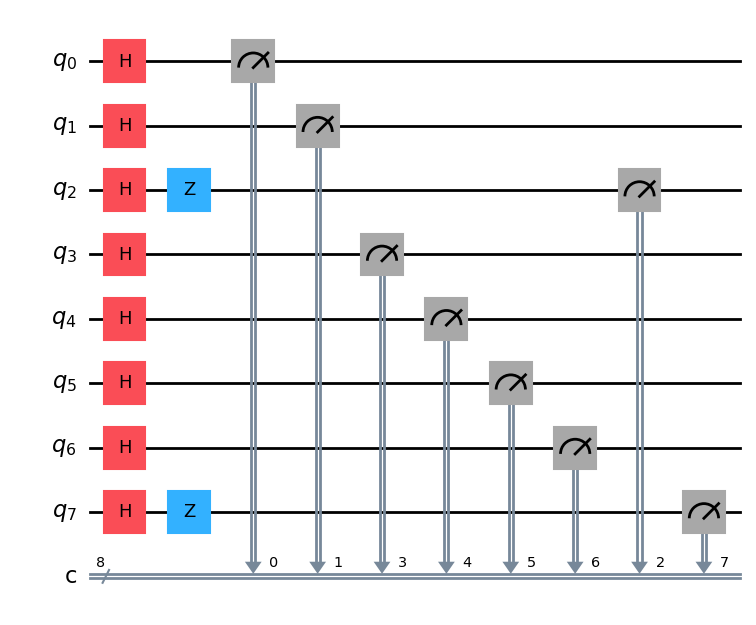

In [ ]:
display_qprf_circuit()

In [ ]:
class KnuthYao:
    def __init__(self, probabilities, outcomes):
        self.probs = probabilities
        self.outcomes = outcomes
        self.max_depth = 0
        self.total = 0
        self.sparse_table = []
        self.build_sparse_table()

    def build_sparse_table(self):
        max_depth = 0
        binary_table = []

        for p in self.probs:
            if p > 0:
                d = math.ceil(-math.log2(p))
                max_depth = max(max_depth, d)
        self.max_depth = max_depth
        self.total = 1 << max_depth  # 2^max_depth

        for i, p in enumerate(self.probs):
            exact = int(p * self.total)
            binary_repr = format(exact, f'0{max_depth}b')
            binary_table.append([int(bit) for bit in binary_repr])

        # Convert binary table into a sparse representation
        self.sparse_table = np.array(binary_table, dtype=int)

    def sample(self):
        row = 0
        col = random.randint(0, self.max_depth - 1)

        while row < len(self.sparse_table) and self.sparse_table[row, col] == 0:
            row += 1

        return self.outcomes[row] if row < len(self.outcomes) else self.outcomes[-1]

In [ ]:
def knuth_yao_sampling(num_polys):
    probabilities = [0.3, 0.4, 0.3]
    outcomes = [-1, 0, 1]
    sampler = KnuthYao(probabilities, outcomes)
    return np.array([[sampler.sample() for _ in range(n)] for _ in range(num_polys)])

In [ ]:
def encrypt(public_key, message):
    A, t = public_key
    message_length = len(message)  # Get actual length

    r = knuth_yao_sampling(k)[:, :message_length]  # Adjust sample size
    e1 = knuth_yao_sampling(k)[:, :message_length]
    e2 = knuth_yao_sampling(1)[:message_length].flatten()  # Ensure shape compatibility

    print("r :", r)
    print("e1 :", e1)
    print("e2 :", e2)

    u = (np.einsum('ijk,jk->ik', A[:, :, :message_length], r) + e1) % q
    v = (np.einsum('ik,ik->k', t[:, :message_length], r) + e2 + (message * L)) % q

    return (u, v)

In [ ]:
def decrypt(private_key, ciphertext):
    s = private_key
    u, v = ciphertext
    m_hat = (v - np.einsum('ik,ik->k', s, u)) % q
    m_centered = np.where(m_hat > q//2, m_hat - q, m_hat)
    m_decoded = np.where(m_centered > (L / 2), 1, 0).flatten()
    return m_decoded.astype(int)

In [ ]:
ciphertext = encrypt(public_key, binary_message)
print("Cipher text", ciphertext)

r : [[-1 -1  1 -1  1  1  1 -1 -1 -1  1 -1  1 -1  1  1 -1  1 -1 -1  1  1 -1  1
  -1  1 -1 -1 -1 -1  1 -1  1 -1  1  1 -1  1 -1  1 -1 -1  1  1 -1 -1  1  1
   1  1  1  1 -1 -1 -1  1  1 -1 -1  1  1  1 -1  1  1  1 -1 -1 -1  1 -1 -1
  -1 -1 -1 -1  1  1  1  1 -1  1 -1  1 -1  1 -1 -1  1  1 -1  1 -1 -1  1 -1
   1  1  1  1  1  1  1 -1  1  1  1 -1 -1  1 -1 -1  1 -1 -1  1 -1 -1  1 -1
  -1  1  1  1  1 -1 -1  1  1  1 -1  1 -1  1 -1 -1  1  1  1  1 -1 -1  1  1
   1 -1 -1 -1 -1 -1  1  1  1 -1  1 -1  1 -1 -1  1  1 -1 -1 -1  1 -1 -1  1
   1  1  1  1 -1 -1  1  1  1 -1 -1 -1 -1  1 -1 -1 -1  1  1 -1  1 -1  1  1
  -1 -1  1 -1  1  1  1  1  1 -1 -1  1  1  1 -1  1 -1  1  1 -1  1  1  1  1
  -1  1 -1  1 -1 -1 -1 -1 -1  1 -1  1  1 -1  1  1 -1 -1  1  1  1 -1 -1 -1
   1 -1  1  1 -1 -1  1 -1 -1 -1  1 -1  1  1  1  1]
 [-1  1  1 -1 -1  1  1  1 -1  1 -1 -1  1  1  1  1  1  1 -1  1  1  1  1 -1
  -1  1  1  1  1  1 -1  1 -1 -1  1  1 -1  1  1  1  1  1 -1 -1 -1  1  1  1
  -1 -1  1 -1  1 -1  1 -1  1 -1  1 -1 -1 -1  1 -1  1  1  

In [ ]:
decrypted_message = decrypt(private_key, ciphertext)

print("Original Message:", message)
print("Decrypted Message:", decrypted_message)
print("Decryption Successful:", np.array_equal(binary_message, decrypted_message))

print("Retreived message", binary_to_string(decrypted_message))

Original Message: Team 34 IPD presentation PQC
Decrypted Message: [0 1 0 1 0 1 0 0 0 1 1 0 0 1 0 1 0 1 1 0 0 0 0 1 0 1 1 0 1 1 0 1 0 0 1 0 0
 0 0 0 0 0 1 1 0 0 1 1 0 0 1 1 0 1 0 0 0 0 1 0 0 0 0 0 0 1 0 0 1 0 0 1 0 1
 0 1 0 0 0 0 0 1 0 0 0 1 0 0 0 0 1 0 0 0 0 0 0 1 1 1 0 0 0 0 0 1 1 1 0 0 1
 0 0 1 1 0 0 1 0 1 0 1 1 1 0 0 1 1 0 1 1 0 0 1 0 1 0 1 1 0 1 1 1 0 0 1 1 1
 0 1 0 0 0 1 1 0 0 0 0 1 0 1 1 1 0 1 0 0 0 1 1 0 1 0 0 1 0 1 1 0 1 1 1 1 0
 1 1 0 1 1 1 0 0 0 1 0 0 0 0 0 0 1 0 1 0 0 0 0 0 1 0 1 0 0 0 1 0 1 0 0 0 0
 1 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
Decryption Successful: True
Retreived message Team 34 IPD presentation PQC    


In [ ]:
def cbd_sampling(num_polys, n, eta=3):
    probabilities = [0.3, 0.4, 0.3]
    outcomes = [-1, 0, 1]

    def sample_cbd_element():
        work = 0
        for _ in range(random.randint(1, 5)):  # Random loop iterations simulate variable work
            work += random.random()
        # Now, select the outcome based on the distribution:
        return np.random.choice(outcomes, p=probabilities)

    return np.array([[sample_cbd_element() for _ in range(n)] for _ in range(num_polys)])

Knuth-Yao Sampling Timing Stats:
  Mean: 0.000648 s
  Std Dev: 0.000133 s
  Min: 0.000598 s
  Max: 0.001731 s
  Runs: 100

CBD Sampling Timing Stats (eta=1):
  Mean: 0.011086 s
  Std Dev: 0.003836 s
  Min: 0.008351 s
  Max: 0.023790 s
  Runs: 100

CBD Sampling Timing Stats (eta=2):
  Mean: 0.010483 s
  Std Dev: 0.003105 s
  Min: 0.008396 s
  Max: 0.023835 s
  Runs: 100

CBD Sampling Timing Stats (eta=3):
  Mean: 0.010132 s
  Std Dev: 0.002764 s
  Min: 0.008357 s
  Max: 0.020013 s
  Runs: 100

CBD Sampling Timing Stats (eta=4):
  Mean: 0.010390 s
  Std Dev: 0.003297 s
  Min: 0.008291 s
  Max: 0.019940 s
  Runs: 100

CBD Sampling Timing Stats (eta=5):
  Mean: 0.012099 s
  Std Dev: 0.004023 s
  Min: 0.008331 s
  Max: 0.023312 s
  Runs: 100



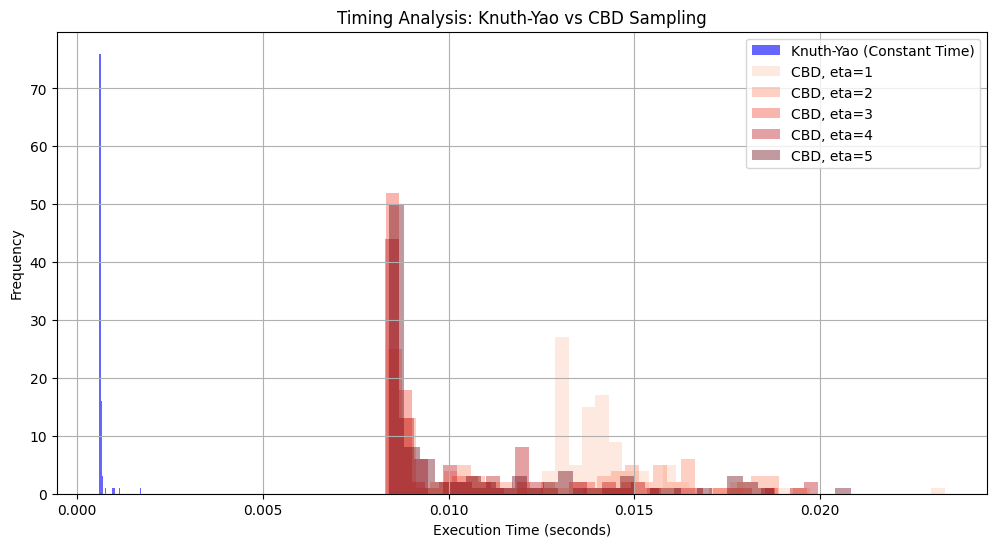

In [ ]:
def measure_time(sampler_func, num_polys, n, eta=None, trials=100):
    times = []
    for _ in range(trials):
        start = time.perf_counter()
        if eta is not None:
            sampler_func(num_polys, n, eta)
        else:
            sampler_func(num_polys)
        times.append(time.perf_counter() - start)
    return np.array(times)

num_trials = 100
num_polys = 2
n = 256

# Measure times for Knuth-Yao (constant-time)
ty_knuth = measure_time(knuth_yao_sampling, num_polys, n, trials=num_trials)

# Stats for Knuth-Yao
print("Knuth-Yao Sampling Timing Stats:")
print(f"  Mean: {np.mean(ty_knuth):.6f} s")
print(f"  Std Dev: {np.std(ty_knuth):.6f} s")
print(f"  Min: {np.min(ty_knuth):.6f} s")
print(f"  Max: {np.max(ty_knuth):.6f} s")
print(f"  Runs: {len(ty_knuth)}\n")

# Measure times for CBD for various eta values
etas = np.array([1, 2, 3, 4, 5]).reshape(-1, 1)
mean_times_cbd = []

for eta in etas.flatten():
    times = measure_time(cbd_sampling, num_polys, n, eta=eta, trials=num_trials)
    mean_times_cbd.append(np.mean(times))

    # Stats for CBD eta
    print(f"CBD Sampling Timing Stats (eta={eta}):")
    print(f"  Mean: {np.mean(times):.6f} s")
    print(f"  Std Dev: {np.std(times):.6f} s")
    print(f"  Min: {np.min(times):.6f} s")
    print(f"  Max: {np.max(times):.6f} s")
    print(f"  Runs: {len(times)}\n")

mean_times_cbd = np.array(mean_times_cbd).reshape(-1, 1)

# Plot timing histograms
plt.figure(figsize=(12, 6))
plt.hist(ty_knuth, bins=30, alpha=0.6, label="Knuth-Yao (Constant Time)", color='blue')
for idx, eta in enumerate(etas.flatten()):
    plt.hist(measure_time(cbd_sampling, num_polys, n, eta=eta, trials=num_trials),
             bins=30, alpha=0.4, label=f"CBD, eta={eta}", color=plt.cm.Reds((idx+1)/len(etas)))
plt.xlabel("Execution Time (seconds)")
plt.ylabel("Frequency")
plt.title("Timing Analysis: Knuth-Yao vs CBD Sampling")
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
# An attacker can build a simple linear model: mean_time = a * eta + b.
# We use our collected (eta, mean_time) pairs to fit a linear regression.
reg = LinearRegression()
reg.fit(etas, mean_times_cbd)

print("Estimated linear model for CBD sampling timing:")
print(f"  Mean Time = {reg.coef_[0, 0]:.6f} * eta + {reg.intercept_[0]:.6f}")

T_unknown = np.mean(measure_time(cbd_sampling, num_polys, n, eta=3, trials=100))
eta_estimated = (T_unknown - reg.intercept_[0]) / reg.coef_[0]
print(f"\nFor an unknown instance (true eta=3) with measured mean time {T_unknown:.6f} s,")
print(f"the estimated eta is: {eta_estimated.item():.2f}")

Estimated linear model for CBD sampling timing:
  Mean Time = 0.000193 * eta + 0.010259

For an unknown instance (true eta=3) with measured mean time 0.011191 s,
the estimated eta is: 4.83
